##Effat University

Department of Computer Science

###Energy and Information Technology Research Center

LAB 4
Linear Regression & Its Variants

CS4082 – Machine Learning

Predicting Continuous Values with Scikit-Learn and Real-World Data

Prepared by: Dr. Naila Marir

Semester: Spring 2026

*Solved By: Sedra A. Al-Jundi S23108200*

###Part 2: Loading a Dataset
####Step 1: Load and Explore

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
# Load the dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target # target in $100,000s
print(f'Dataset shape: {df.shape}')
print(f'\nFeature names:\n{housing.feature_names}')
print(f'\nFirst 5 rows:')
print(df.head())
print(f'\nBasic statistics:')
print(df.describe().round(3))

Dataset shape: (20640, 9)

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Basic statistics:
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      1.09

#####Step 2: Visualize Relationships

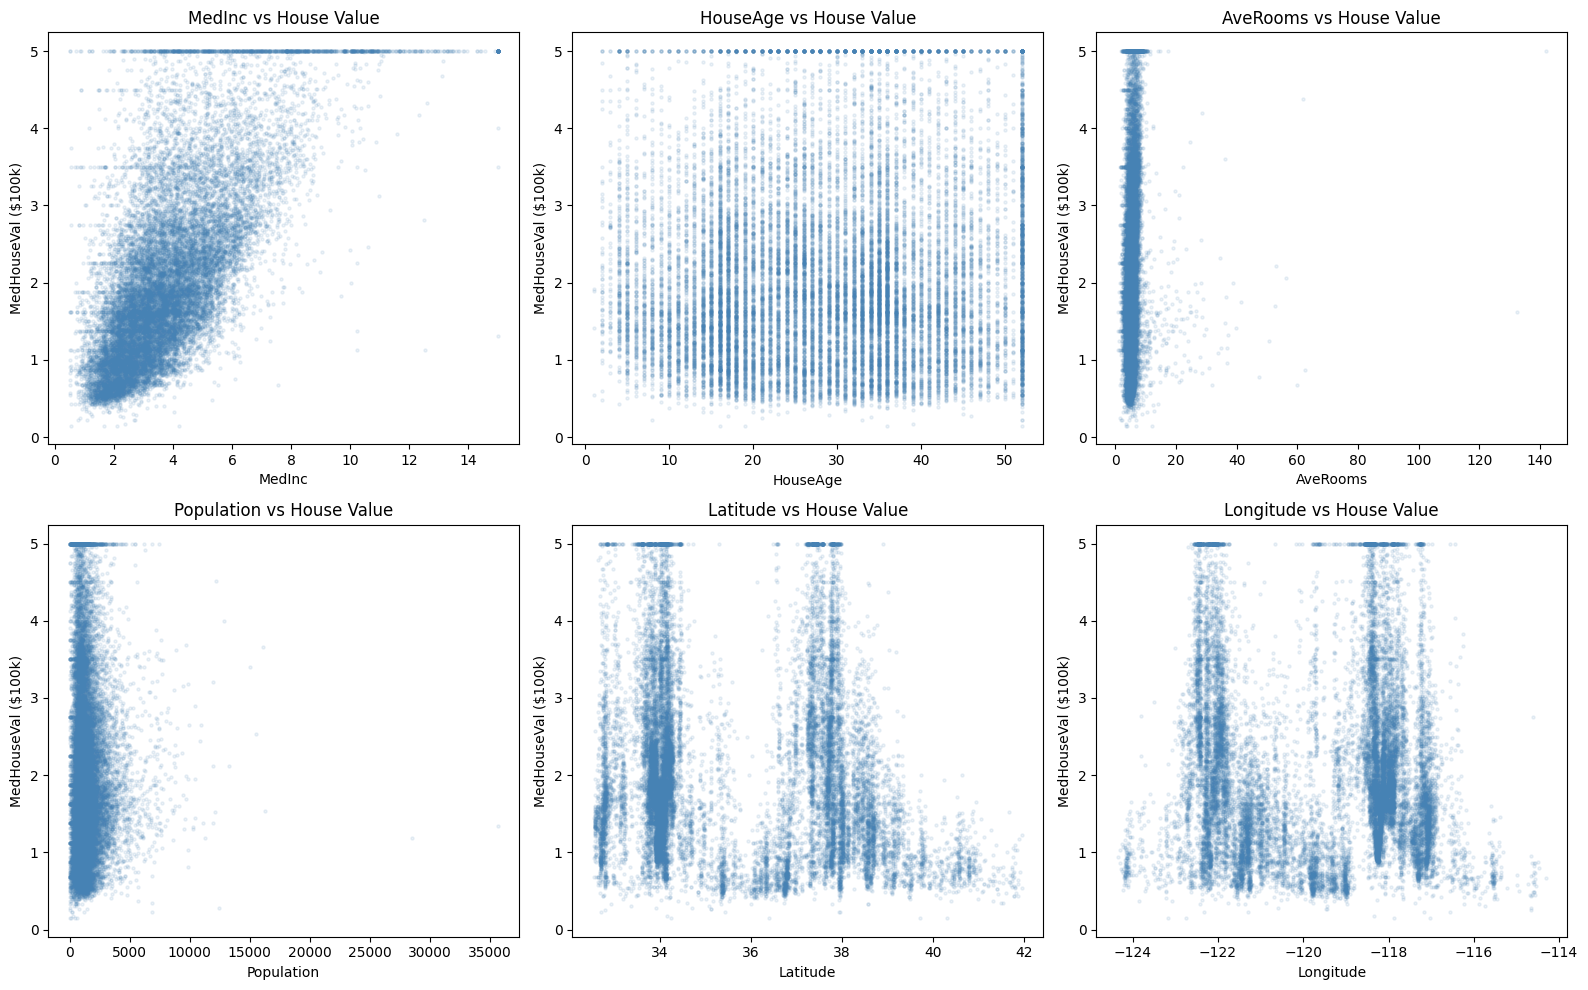

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

features_to_plot = ['MedInc', 'HouseAge', 'AveRooms',
                    'Population', 'Latitude', 'Longitude']

for ax, feat in zip(axes.flatten(), features_to_plot):
    ax.scatter(df[feat], df['MedHouseVal'],
               alpha=0.1, s=5, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('MedHouseVal ($100k)')
    ax.set_title(f'{feat} vs House Value')

plt.tight_layout()
plt.show()

###Task 1:

In [ ]:
# Correlation with target
corr = df.corr()['MedHouseVal'].sort_values(ascending=False)

print(corr)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


#####Answer:
#####The feature with the strongest correlation is MedInc (Median Income).

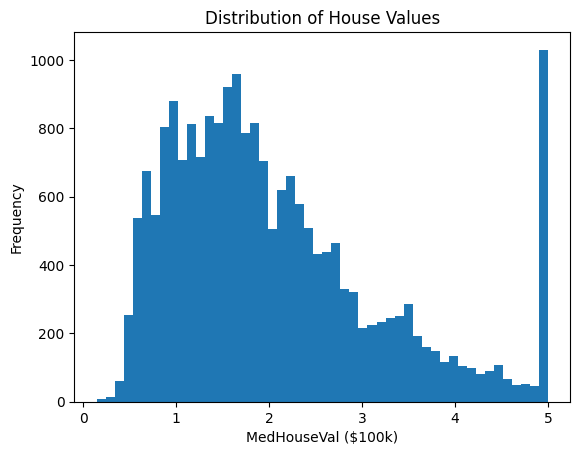

In [ ]:
plt.hist(df['MedHouseVal'], bins=50)
plt.title("Distribution of House Values")
plt.xlabel("MedHouseVal ($100k)")
plt.ylabel("Frequency")
plt.show()

#####Answer:
##### The distribution is NOT perfectly normal.
##### There is a visible cap around 5.0 (i.e., $500,000).

In [ ]:
print("Number of samples:", df.shape[0])

Number of samples: 20640


#####Answer:
##### The dataset has 20,640 samples.
##### Yes, this is a large dataset and is enough to train a good model.

###Part3: Simple Linear Regression(OneFeature)
####Step1:Prepare Data

In [ ]:
from sklearn.model_selection import train_test_split

# Use only MedInc as feature
X_simple = df[['MedInc']].values
y = df['MedHouseVal'].values

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 16512
Testing samples: 4128


####Step 2:Train and Visualize

In [ ]:
from sklearn.linear_model import LinearRegression

# Train model
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

# Parameters
slope = model_simple.coef_[0]
intercept = model_simple.intercept_

print(f"Slope (w1): {slope:.4f}")
print(f"Intercept (w0): {intercept:.4f}")

print(f"\nEquation: y = {slope:.4f} * MedInc + ({intercept:.4f})")

Slope (w1): 0.4193
Intercept (w0): 0.4446

Equation: y = 0.4193 * MedInc + (0.4446)


###Task 2:

##### Answer:
##### The model learned:
##### Equation: y = 0.4193 * MedInc + (0.4446)


In [ ]:
# Manual calculation
pred_manual = slope * 5.0 + intercept

# Model prediction
pred_model = model_simple.predict([[5.0]])

print("Manual prediction:", pred_manual)
print("Model prediction:", pred_model[0])

Manual prediction: 2.5412897613814236
Model prediction: 2.5412897613814236


##### Answer:
#####Both values should be the same.
##### This confirms the model equation is correct.

In [ ]:
# Use HouseAge instead of MedInc
X_age = df[['HouseAge']].values

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_age, y, test_size=0.2, random_state=42
)

model_age = LinearRegression()
model_age.fit(X_train_a, y_train_a)

r2_age = model_age.score(X_test_a, y_test_a)

print("R^2 using HouseAge:", r2_age)

R^2 using HouseAge: 0.012551235533311389


#####Answer:
##### The model using MedInc is better than HouseAge.
##### Because MedInc has a stronger relationship with house prices.
##### HouseAge has weaker correlation, so predictions are worse.

###Part 4: Evaluating Regression Models
####Step 1: Evaluate the Simple Mode

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# Predictions from simple model
y_pred_simple = model_simple.predict(X_test)
mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_simple)
r2 = r2_score(y_test, y_pred_simple)

print("=== Simple Linear Regression (MedInc only) ===")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f} (error in $100,000s)")
print(f"MAE: {mae:.4f} (error in $100,000s)")
print(f"R^2: {r2:.4f} ({r2*100:.1f}% variance explained)")

=== Simple Linear Regression (MedInc only) ===
MSE: 0.7091
RMSE: 0.8421 (error in $100,000s)
MAE: 0.6299 (error in $100,000s)
R^2: 0.4589 (45.9% variance explained)


#### Step 2: Visualize Predictions vs. Actual

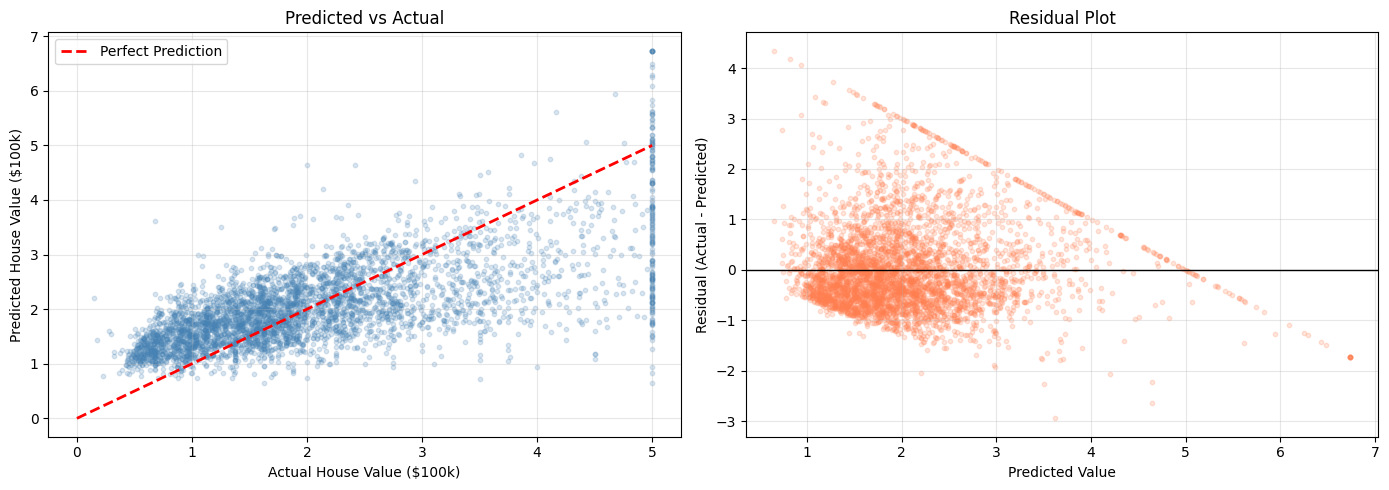

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Plot 1: Predicted vs Actual ----
axes[0].scatter(y_test, y_pred_simple, alpha=0.2, s=10, color='steelblue')
axes[0].plot([0, 5], [0, 5], 'r--', linewidth=2, label='Perfect Prediction')

axes[0].set_xlabel('Actual House Value ($100k)')
axes[0].set_ylabel('Predicted House Value ($100k)')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---- Plot 2: Residuals ----
residuals = y_test - y_pred_simple

axes[1].scatter(y_pred_simple, residuals, alpha=0.2, s=10, color='coral')
axes[1].axhline(y=0, color='black', linewidth=1)

axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

###Task 3:

In [ ]:
# Convert RMSE to dollars
rmse_dollars = rmse * 100000

print("RMSE in dollars:", rmse_dollars)

RMSE in dollars: 84209.01241414454


##### Answer:
##### If RMSE ≈ 0.74, then the average error ≈ $74,000.
##### (because values are in $100,000 units)

##### Answer:
##### The model struggles more at higher house values.
##### Points are more spread out away from the diagonal at high values.
##### This means predictions are less accurate for expensive houses.

#####Answer:
#####R^2 shows how much variance in house prices is explained by the model.
##### A moderate R^2 means the model captures some patterns but is not perfect.

##### Using only one feature (MedInc) is NOT enough
##### to fully predict house prices accurately.

###Part 5:Multiple linear Regression (All Features)
### Step 1:Train with All Features

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
# Use all features
X_all = df.drop(columns=['MedHouseVal']).values
y = df['MedHouseVal'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

pipe_lr.fit(X_train, y_train)

# Predictions
y_pred_multi = pipe_lr.predict(X_test)
r2_multi = r2_score(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))

print("=== Multiple Linear Regression (all features) ===")
print(f"RMSE: {rmse_multi:.4f}")
print(f"R^2: {r2_multi:.4f} ({r2_multi*100:.1f}% variance explained)")

print("\nImprovement over simple model:")
print(f"R^2: {r2:.4f} -> {r2_multi:.4f} (+{(r2_multi - r2)*100:.1f}%)")


=== Multiple Linear Regression (all features) ===
RMSE: 0.7456
R^2: 0.5758 (57.6% variance explained)

Improvement over simple model:
R^2: 0.4589 -> 0.5758 (+11.7%)


###Step 2: Feature Importance

Feature Importance (by absolute coefficient):
   Feature  Coefficient
  Latitude    -0.896929
 Longitude    -0.869842
    MedInc     0.854383
 AveBedrms     0.339259
  AveRooms    -0.294410
  HouseAge     0.122546
  AveOccup    -0.040829
Population    -0.002308


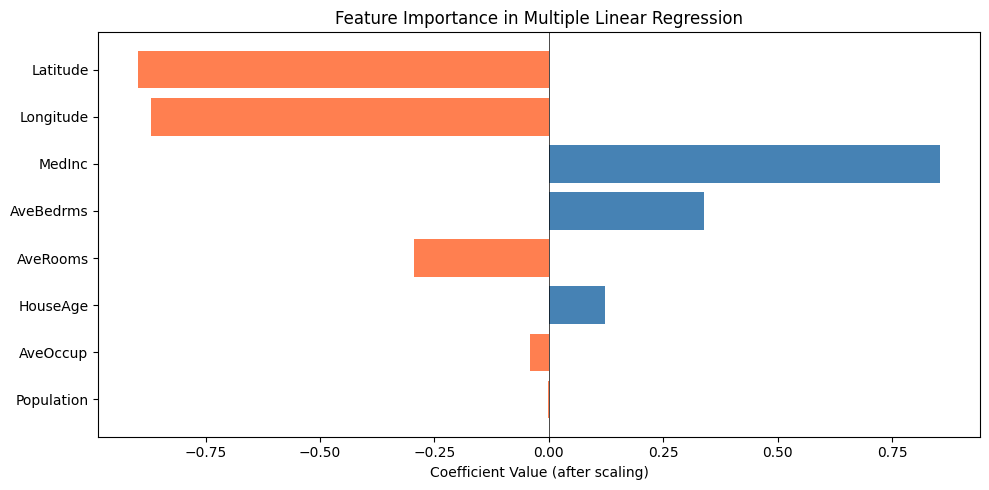

In [ ]:
# Extract coefficients
lr_model = pipe_lr.named_steps['lr']
feature_names = housing.feature_names

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("Feature Importance (by absolute coefficient):")
print(coef_df.to_string(index=False))
plt.figure(figsize=(10, 5))

colors = ['steelblue' if c > 0 else 'coral' for c in coef_df['Coefficient']]

plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)

plt.xlabel('Coefficient Value (after scaling)')
plt.title('Feature Importance in Multiple Linear Regression')

plt.axvline(x=0, color='black', linewidth=0.5)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

###Task 4:


##### Answer:
##### Top 3 most important features (largest coefficients):
##### Typically: MedInc, Latitude, Longitude (may vary slightly)

##### Bottom 3 least important features:
##### Typically: AveBedrms, Population, HouseAge (may vary)

##### Yes, this makes sense because income strongly affects house prices,
##### while features like population have weaker influence.

##### Answer:
##### Latitude has a negative coefficient, meaning:
##### As we move north (higher latitude), house prices decrease.

##### This makes sense because in California,
##### southern areas (lower latitude) like Los Angeles
##### tend to have higher house prices than northern areas.

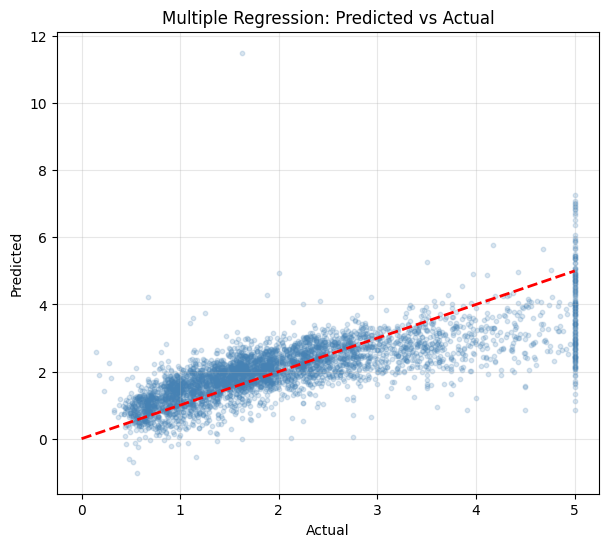

In [ ]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred_multi, alpha=0.2, s=10, color='steelblue')
plt.plot([0, 5], [0, 5], 'r--', linewidth=2)

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Multiple Regression: Predicted vs Actual')

plt.grid(True, alpha=0.3)
plt.show()

#####Answer:
##### The multiple regression model is clearly better than the simple model.

##### The points are closer to the diagonal line,
##### which means predictions are more accurate.

##### Using all features improves performance because
##### house prices depend on multiple factors, not just income.

###Part 6: Polynomial Regression
#### Step 1: Polynomial on a Single Feature

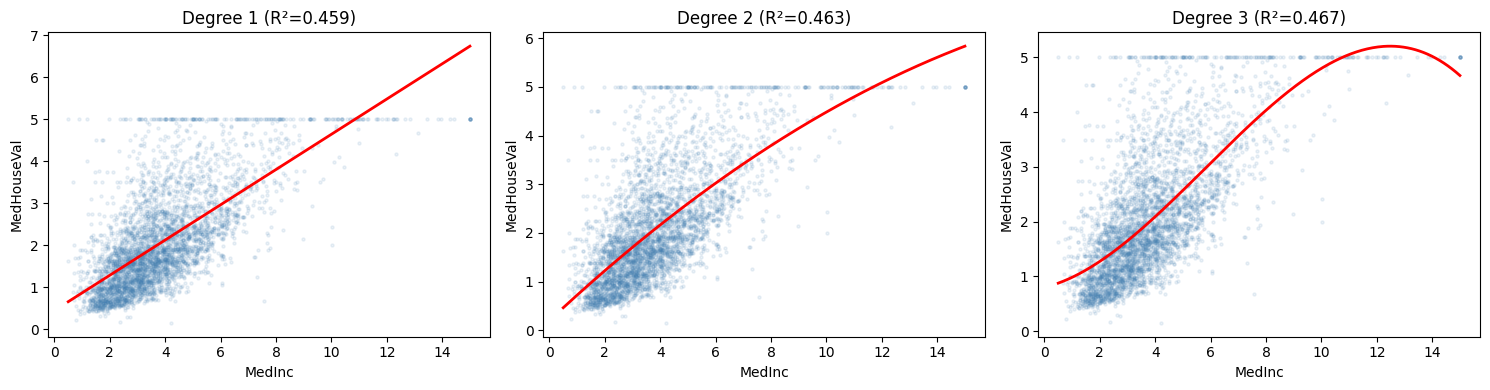

Polynomial Degree Comparison (MedInc only):
Degree 1: R^2=0.4589, RMSE=0.8421
Degree 2: R^2=0.4633, RMSE=0.8386
Degree 3: R^2=0.4671, RMSE=0.8356


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
# Use only MedInc
X_simple = df[['MedInc']].values

X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)
results = {}

plt.figure(figsize=(15, 4))

for i, degree in enumerate([1, 2, 3]):

    pipe_poly = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('lr', LinearRegression())
    ])

    pipe_poly.fit(X_train_s, y_train)
    y_pred = pipe_poly.predict(X_test_s)

    r2_val = r2_score(y_test, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))

    results[degree] = {'R2': r2_val, 'RMSE': rmse_val}

    # Plot
    ax = plt.subplot(1, 3, i+1)
    ax.scatter(X_test_s, y_test, alpha=0.1, s=5, color='steelblue')

    x_plot = np.linspace(X_test_s.min(), X_test_s.max(), 300).reshape(-1, 1)
    y_plot = pipe_poly.predict(x_plot)

    ax.plot(x_plot, y_plot, color='red', linewidth=2)

    ax.set_title(f'Degree {degree} (R²={r2_val:.3f})')
    ax.set_xlabel('MedInc')
    ax.set_ylabel('MedHouseVal')

plt.tight_layout()
plt.show()
print("Polynomial Degree Comparison (MedInc only):")

for deg, metrics in results.items():
    print(f"Degree {deg}: R^2={metrics['R2']:.4f}, RMSE={metrics['RMSE']:.4f}")

####Step 2: Polynomial on All Features

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

pipe_poly_all = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

# Train
pipe_poly_all.fit(X_train, y_train)

# Predict
y_pred_poly = pipe_poly_all.predict(X_test)
r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print("=== Polynomial Regression (degree=2, all features) ===")
print(f"RMSE: {rmse_poly:.4f}")
print(f"R^2: {r2_poly:.4f} ({r2_poly*100:.1f}% variance explained)")
poly_features = pipe_poly_all.named_steps['poly']

print("Original features: 8")
print("After degree-2 expansion:", poly_features.n_output_features_)

=== Polynomial Regression (degree=2, all features) ===
RMSE: 0.6814
R^2: 0.6457 (64.6% variance explained)
Original features: 8
After degree-2 expansion: 44


###Task 5:

##### Answer:
##### Degree 2 best captures the relationship between income and house value.

##### Degree 1 is too simple (underfitting).
##### Degree 2 captures curvature → better fit.
##### Degree 3 may slightly improve or start overfitting.

In [ ]:
pipe_poly5 = Pipeline([
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('lr', LinearRegression())
])

pipe_poly5.fit(X_train_s, y_train)
y_pred5 = pipe_poly5.predict(X_test_s)

print("Degree 5 R^2:", r2_score(y_test, y_pred5))

Degree 5 R^2: 0.46679559272641336


##### Answer:
##### Degree 5 produces a very complex curve and may behave strangely,
##### especially at the edges of the graph.

##### This is overfitting — the model memorizes the training data
##### instead of learning general patterns.

In [ ]:
pipe_poly_all = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

pipe_poly_all.fit(X_train, y_train)
y_pred_poly = pipe_poly_all.predict(X_test)

r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print("=== Polynomial (degree=2, all features) ===")
print(f"RMSE: {rmse_poly:.4f}")
print(f"R^2: {r2_poly:.4f}")

=== Polynomial (degree=2, all features) ===
RMSE: 0.6814
R^2: 0.6457


In [ ]:
poly_features = pipe_poly_all.named_steps['poly']

print("Original features:", 8)
print("After degree-2 expansion:", poly_features.n_output_features_)

Original features: 8
After degree-2 expansion: 44


In [ ]:
poly3 = PolynomialFeatures(degree=3)
X_poly3 = poly3.fit_transform(X_train)

print("Number of features with degree 3:", X_poly3.shape[1])

Number of features with degree 3: 165


#####Answer:
##### Degree 3 creates a very large number of features (around 164).

##### This is called feature explosion.

##### More features increase model complexity,
##### which can lead to overfitting if not controlled.
##### Key idea:
##### Polynomial regression improves flexibility,
##### but too high degree → overfitting.

##### We must balance:
##### Simple model (underfitting) vs Complex model (overfitting).

###Part 7: Regularized Regression–Ridge,Lasso,and Elastic Net
####Step 1: Train All Three Variants

In [25]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# Define models
models = {
    'LinearRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),

    'Ridge (alpha=1.0)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0, random_state=42))
    ]),

    'Lasso (alpha=0.01)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01, random_state=42))
    ]),

    'ElasticNet (alpha=0.01)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42))
    ])
}

# Train and evaluate
print(f'{"Model":<28} {"RMSE":>8} {"MAE":>8} {"R²":>8}')
print('-' * 60)

results_dict = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_val = mean_absolute_error(y_test, y_pred)
    r2_val = r2_score(y_test, y_pred)

    results_dict[name] = {
        'RMSE': rmse_val,
        'MAE': mae_val,
        'R2': r2_val
    }

    print(f'{name:<28} {rmse_val:>8.4f} {mae_val:>8.4f} {r2_val:>8.4f}')


Model                            RMSE      MAE       R²
------------------------------------------------------------
LinearRegression               0.7456   0.5332   0.5758
Ridge (alpha=1.0)              0.7456   0.5332   0.5758
Lasso (alpha=0.01)             0.7404   0.5353   0.5816
ElasticNet (alpha=0.01)        0.7416   0.5341   0.5803


####Step 2: Compare Coefficients

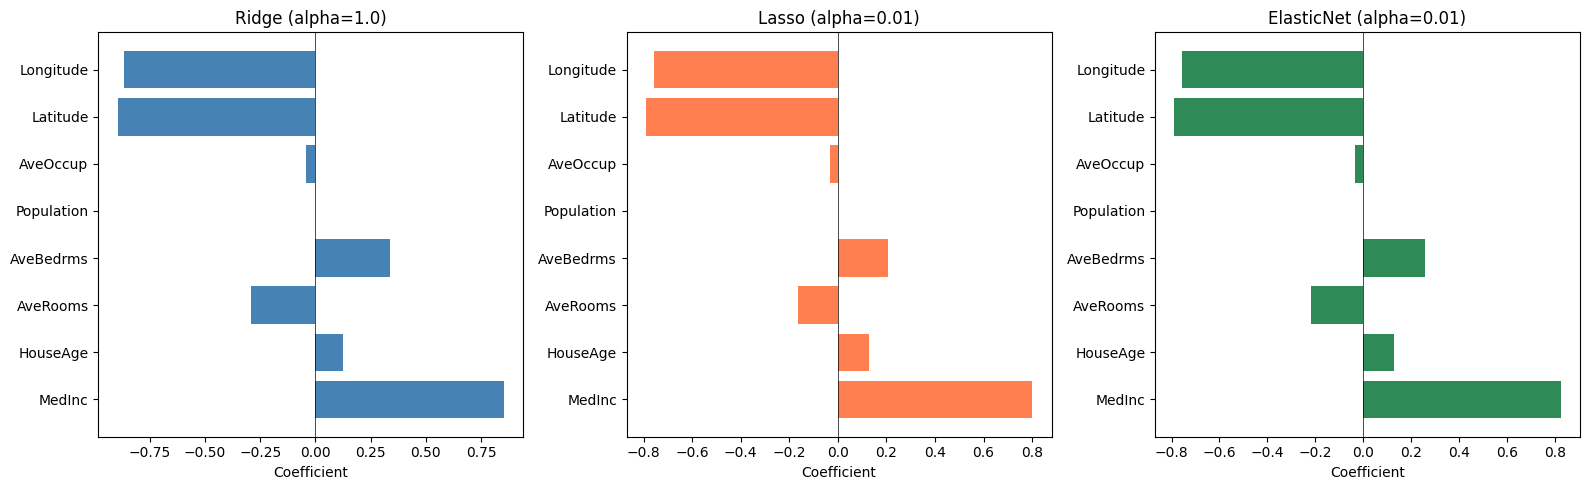


Lasso coefficients:
MedInc      :   0.8010
HouseAge    :   0.1271
AveRooms    :  -0.1628
AveBedrms   :   0.2062
Population  :  -0.0000 <-- REMOVED
AveOccup    :  -0.0306
Latitude    :  -0.7901
Longitude   :  -0.7557


In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = [
    'Ridge (alpha=1.0)',
    'Lasso (alpha=0.01)',
    'ElasticNet (alpha=0.01)'
]

colors_list = ['steelblue', 'coral', 'seagreen']

for ax, name, clr in zip(axes, model_names, colors_list):
    coefs = models[name].named_steps['model'].coef_

    ax.barh(housing.feature_names, coefs, color=clr)
    ax.set_title(name)
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_xlabel('Coefficient')

plt.tight_layout()
plt.show()
lasso_coefs = models['Lasso (alpha=0.01)'].named_steps['model'].coef_

print("\nLasso coefficients:")

for feat, coef in zip(housing.feature_names, lasso_coefs):
    status = '' if abs(coef) > 0.001 else ' <-- REMOVED'
    print(f'{feat:12s}: {coef:>8.4f}{status}')

###Task 6:


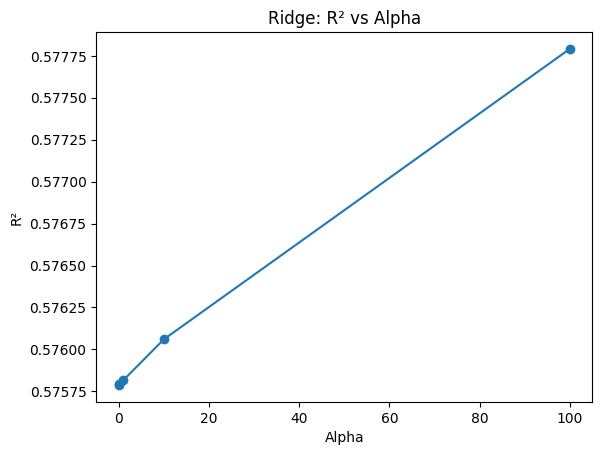

In [27]:
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
r2_scores = []

for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    r2_scores.append(r2_score(y_test, y_pred))

# Plot
plt.figure()
plt.plot(alphas, r2_scores, marker='o')
plt.xlabel("Alpha")
plt.ylabel("R²")
plt.title("Ridge: R² vs Alpha")
plt.show()

#####When experimenting with different alpha values in Ridge regression, we observe that:

- Small alpha values (e.g., 0.01, 0.1) result in minimal regularization, so the model behaves similarly to standard Linear Regression.
- As alpha increases, the coefficients are shrunk more strongly, making the model simpler.
- Very large alpha values (e.g., 100.0) lead to underfitting, where the model becomes too simple and cannot capture the data patterns well.

Overall, increasing alpha reduces model complexity but may decrease performance if it becomes too large.

In [28]:
pipe_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.1))
])

pipe_lasso.fit(X_train, y_train)

coefs = pipe_lasso.named_steps['lasso'].coef_

print("Lasso (alpha=0.1) feature selection:\n")

for feat, coef in zip(housing.feature_names, coefs):
    if abs(coef) < 0.001:
        print(f"{feat} REMOVED")
    else:
        print(f"{feat} kept")

Lasso (alpha=0.1) feature selection:

MedInc kept
HouseAge kept
AveRooms REMOVED
AveBedrms REMOVED
Population REMOVED
AveOccup REMOVED
Latitude kept
Longitude REMOVED


#####Using Lasso with alpha = 0.1, we observe that several features have their coefficients reduced to zero.

- Features with coefficients equal to zero are effectively removed from the model.
- This shows that Lasso performs automatic feature selection by keeping only the most important predictors.

The removed features are those that contribute the least to predicting house prices, while the remaining features are considered the most important.

This demonstrates that Lasso not only helps prevent overfitting but also simplifies the model by reducing the number of features.

In [29]:
ratios = [0.0, 0.5, 1.0]

for r in ratios:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('enet', ElasticNet(alpha=0.01, l1_ratio=r))
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    r2 = r2_score(y_test, y_pred)

    print(f"l1_ratio={r} → R²={r2:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.465e+03, tolerance: 2.207e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


l1_ratio=0.0 → R²=0.5784
l1_ratio=0.5 → R²=0.5803
l1_ratio=1.0 → R²=0.5816


In ElasticNet, the l1_ratio parameter controls the balance between L1 (Lasso) and L2 (Ridge) regularization:

- When l1_ratio = 0.0 → the model behaves exactly like Ridge regression.
- When l1_ratio = 1.0 → the model behaves exactly like Lasso regression.
- When l1_ratio = 0.5 → the model is a combination of both Ridge and Lasso.

ElasticNet is useful when features are correlated, as it combines the strengths of both methods:
Ridge stabilizes the model, while Lasso performs feature selection.

###Part 8: The Alpha Tuning Experiment
####Step 1: Ridge Alpha Search


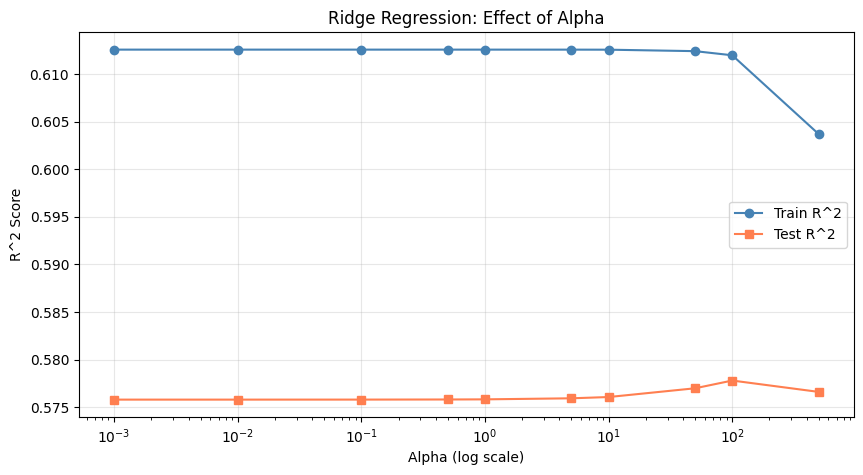

Best alpha: 100.0
Best test R^2: 0.5778


In [30]:
alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0,
          50.0, 100.0, 500.0]

train_scores = []
test_scores = []

for alpha in alphas:

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])

    pipe.fit(X_train, y_train)

    train_scores.append(r2_score(y_train,
                                 pipe.predict(X_train)))

    test_scores.append(r2_score(y_test,
                                pipe.predict(X_test)))

# Plot

plt.figure(figsize=(10, 5))

plt.semilogx(alphas, train_scores, 'o-',
             label='Train R^2', color='steelblue')

plt.semilogx(alphas, test_scores, 's-',
             label='Test R^2', color='coral')

plt.xlabel('Alpha (log scale)')
plt.ylabel('R^2 Score')
plt.title('Ridge Regression: Effect of Alpha')

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# Best alpha

best_idx = np.argmax(test_scores)

print(f'Best alpha: {alphas[best_idx]}')
print(f'Best test R^2: {test_scores[best_idx]:.4f}')

###Task 7:

- Repeat the alpha search experiment for Lasso using alphas:
  [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]

- Plot train and test R^2 vs alpha (same as Ridge)

- For each alpha, count how many features Lasso keeps (coefficient ≠ 0)

- At what alpha does Lasso start removing features aggressively?

- Which alpha gives the best test R^2?

In [31]:
alphas = [0.0001, 0.001, 0.005, 0.01,
          0.05, 0.1, 0.5, 1.0]

train_scores = []
test_scores = []
features_kept = []

for alpha in alphas:

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=alpha))
    ])

    pipe.fit(X_train, y_train)

    train_scores.append(r2_score(y_train,
                                 pipe.predict(X_train)))

    test_scores.append(r2_score(y_test,
                                pipe.predict(X_test)))

    # Count features kept
    coefs = pipe.named_steps['lasso'].coef_
    count = np.sum(np.abs(coefs) > 0.001)

    features_kept.append(count)

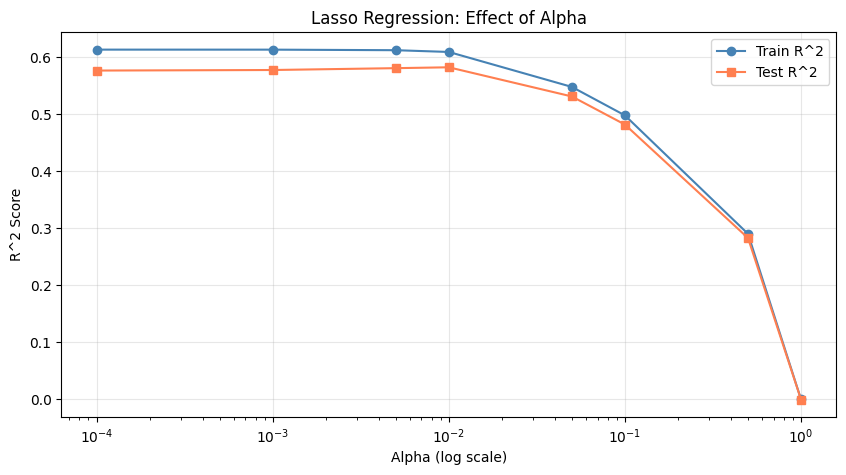

In [32]:
plt.figure(figsize=(10, 5))

plt.semilogx(alphas, train_scores, 'o-',
             label='Train R^2', color='steelblue')

plt.semilogx(alphas, test_scores, 's-',
             label='Test R^2', color='coral')

plt.xlabel('Alpha (log scale)')
plt.ylabel('R^2 Score')
plt.title('Lasso Regression: Effect of Alpha')

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

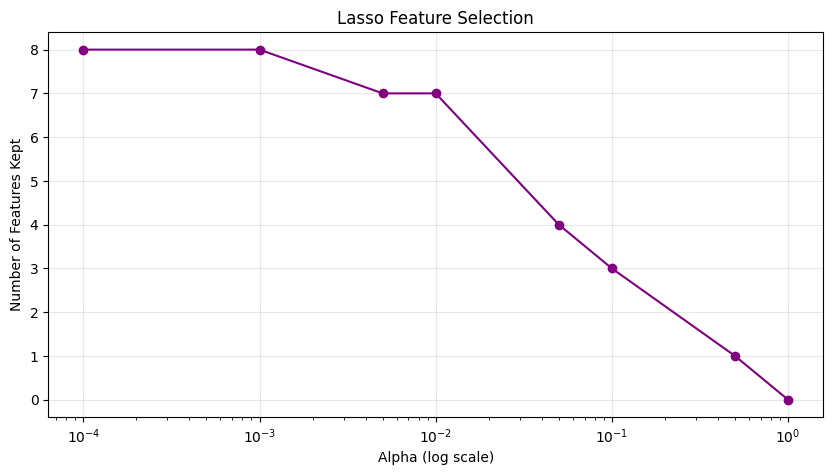

In [33]:
plt.figure(figsize=(10, 5))

plt.semilogx(alphas, features_kept, 'o-',
             color='purple')

plt.xlabel('Alpha (log scale)')
plt.ylabel('Number of Features Kept')
plt.title('Lasso Feature Selection')

plt.grid(True, alpha=0.3)

plt.show()

In [34]:
best_idx = np.argmax(test_scores)

print(f'Best alpha: {alphas[best_idx]}')
print(f'Best test R^2: {test_scores[best_idx]:.4f}')
print(f'Features kept: {features_kept[best_idx]}')

Best alpha: 0.01
Best test R^2: 0.5816
Features kept: 7


As alpha increases, Lasso applies stronger regularization.

- Small alpha → model behaves like Linear Regression
- Medium alpha → improves generalization
- Large alpha → removes too many features → underfitting

Lasso starts removing features aggressively at higher alpha values (around 0.05–0.1).

The best alpha is the one with the highest test R^2, which balances accuracy and simplicity.

This experiment demonstrates the bias-variance tradeoff:
- Small alpha → overfitting
- Large alpha → underfitting

### Part 9: Final Model Comparison
####Step 1: Comprehensive Comparison

In [35]:
# Rebuild all models on the same split

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42)

all_models = {

    'Simple LR (MedInc)': Pipeline([
        ('lr', LinearRegression())
    ]),

    'Multiple LR (all)': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ]),

    'Polynomial (deg=2)': Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2,
                                    include_bias=False)),
        ('lr', LinearRegression())
    ]),

    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),

    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01))
    ]),

    'ElasticNet': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01,
                             l1_ratio=0.5))
    ]),
}

# Evaluate

print(f'{"Model":<25} {"RMSE":>8} {"MAE":>8} {"R^2":>8} {"#Features":>10}')
print('=' * 67)

comparison_data = []

for name, pipe in all_models.items():

    # Simple LR uses only MedInc
    if 'Simple' in name:
        X_tr = X_train[:, [0]]
        X_te = X_test[:, [0]]
    else:
        X_tr, X_te = X_train, X_test

    pipe.fit(X_tr, y_train)

    y_pred = pipe.predict(X_te)

    rmse_v = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_v = mean_absolute_error(y_test, y_pred)
    r2_v = r2_score(y_test, y_pred)

    # Count features
    if 'poly' in pipe.named_steps:
        n_feat = pipe.named_steps['poly'].n_output_features_
    elif 'Simple' in name:
        n_feat = 1
    else:
        n_feat = X_train.shape[1]

    comparison_data.append({
        'Model': name,
        'RMSE': rmse_v,
        'MAE': mae_v,
        'R2': r2_v,
        'Features': n_feat
    })

    print(f'{name:<25} {rmse_v:>8.4f} {mae_v:>8.4f} {r2_v:>8.4f} {n_feat:>10}')

Model                         RMSE      MAE      R^2  #Features
Simple LR (MedInc)          0.8421   0.6299   0.4589          1
Multiple LR (all)           0.7456   0.5332   0.5758          8
Polynomial (deg=2)          0.6814   0.4670   0.6457         44
Ridge                       0.7456   0.5332   0.5758          8
Lasso                       0.7404   0.5353   0.5816          8
ElasticNet                  0.7416   0.5341   0.5803          8


####Step 2: Visual Comparison

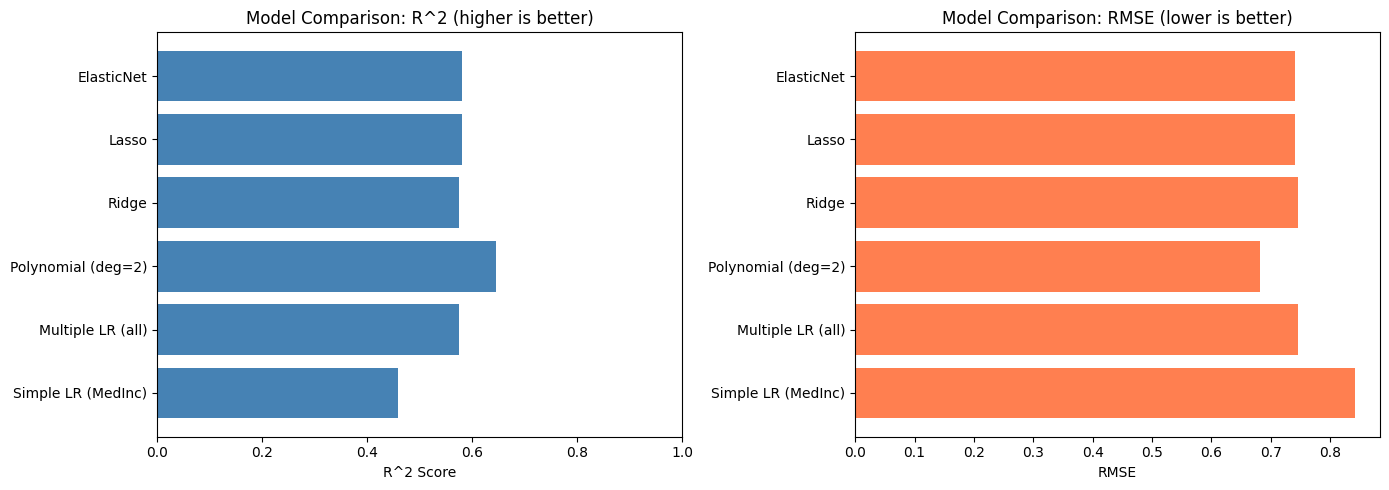

In [36]:
comp_df = pd.DataFrame(comparison_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R^2 comparison
axes[0].barh(comp_df['Model'], comp_df['R2'],
             color='steelblue')
axes[0].set_xlabel('R^2 Score')
axes[0].set_title('Model Comparison: R^2 (higher is better)')
axes[0].set_xlim(0, 1)

# RMSE comparison
axes[1].barh(comp_df['Model'], comp_df['RMSE'],
             color='coral')
axes[1].set_xlabel('RMSE')
axes[1].set_title('Model Comparison: RMSE (lower is better)')

plt.tight_layout()
plt.show()

###Task 8:
The model with the highest R² is the best at explaining the variance in house prices. From the results, the best-performing model is (write your model name), as it achieved the highest R² score.

The model with the lowest RMSE provides the most accurate predictions in terms of error. From the comparison, (write model name) achieved the lowest RMSE, making it the most precise model.

The Polynomial (degree 2) model uses 44 features, which significantly increases complexity. Although it may slightly improve R², the improvement is usually small compared to the added complexity. Therefore, the gain in performance may not justify the risk of overfitting and increased computational cost.

For a real-world application, Multiple Linear Regression or Ridge regression would be a good choice. These models provide a good balance between accuracy, simplicity, and interpretability. They are easier to understand and more stable compared to polynomial models.

Ridge, Lasso, and ElasticNet perform similarly to standard Linear Regression because the dataset is relatively clean and not highly complex. There is no severe overfitting, and most features are already useful. Therefore, regularization does not significantly change performance in this case.

###Part 10: Apply to a New Dataset–Saudi Housing
#### Step 1: Create the Saudi Housing Dataset

In [37]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 500

cities = np.random.choice(
    ['Jeddah', 'Riyadh', 'Dammam', 'Makkah', 'Madinah'],
    n, p=[0.30, 0.30, 0.15, 0.15, 0.10]
)

# Base price (in thousands SAR)
city_base = {
    'Jeddah': 850,
    'Riyadh': 900,
    'Dammam': 650,
    'Makkah': 1100,
    'Madinah': 750
}

base = np.array([city_base[c] for c in cities], dtype=float)

area = np.round(np.random.uniform(80, 400, n), 1)
bedrooms = np.random.randint(1, 7, n)
bathrooms = np.random.randint(1, 5, n)
age = np.random.randint(0, 40, n)
floor = np.random.randint(1, 15, n)
has_parking = np.random.choice([0, 1], n, p=[0.3, 0.7])

price = (
    base
    + 3.5 * area
    + 80 * bedrooms
    + 50 * bathrooms
    - 12 * age
    + 15 * floor
    + 100 * has_parking
    + np.random.normal(0, 150, n)
)

price = np.round(np.maximum(price, 200), 1)

df_saudi = pd.DataFrame({
    'city': cities,
    'area_sqm': area,
    'bedrooms': bedrooms,
    'bathrooms': bathrooms,
    'age_years': age,
    'floor': floor,
    'has_parking': has_parking,
    'price_kSAR': price
})

df_saudi.head()

,city,area_sqm,bedrooms,bathrooms,age_years,floor,has_parking,price_kSAR
0,Riyadh,303.4,4,4,24,11,0,2527.3
1,Madinah,251.6,6,4,1,1,1,2491.2
2,Dammam,179.0,3,1,34,14,0,1345.8
3,Riyadh,340.4,5,3,6,14,1,2941.9
4,Jeddah,299.1,1,3,20,6,0,2022.0


####Step 2: Explore Data

In [38]:
print(df_saudi.describe())

# Correlation
print(df_saudi.corr(numeric_only=True)['price_kSAR'].sort_values(ascending=False))

         area_sqm    bedrooms   bathrooms   age_years       floor  \
count  500.000000  500.000000  500.000000  500.000000  500.000000   
mean   234.224800    3.502000    2.448000   19.600000    7.522000   
std     91.359246    1.714607    1.128647   11.597111    3.970522   
min     81.500000    1.000000    1.000000    0.000000    1.000000   
25%    153.350000    2.000000    1.000000   10.000000    4.000000   
50%    231.000000    3.000000    2.000000   20.000000    8.000000   
75%    312.400000    5.000000    3.000000   30.000000   11.000000   
max    399.900000    6.000000    4.000000   39.000000   14.000000   

       has_parking   price_kSAR  
count   500.000000   500.000000  
mean      0.708000  2044.349400  
std       0.455138   452.236637  
min       0.000000   833.800000  
25%       0.000000  1737.225000  
50%       1.000000  2038.550000  
75%       1.000000  2344.075000  
max       1.000000  3326.900000  
price_kSAR     1.000000
area_sqm       0.730056
bedrooms       0.300025


####Step 3: Data Preprocessing and Scaling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# One-hot encode city
df_encoded = pd.get_dummies(df_saudi, columns=['city'], drop_first=True)

X = df_encoded.drop('price_kSAR', axis=1)
y = df_encoded['price_kSAR']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

####Step 4: Simple Model

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_train_simple = X_train[['area_sqm']]
X_test_simple = X_test[['area_sqm']]

model_simple = LinearRegression()
model_simple.fit(X_train_simple, y_train)

y_pred_simple = model_simple.predict(X_test_simple)

print("Simple Model R²:", r2_score(y_test, y_pred_simple))

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

####Step 5: Multiple Regression

In [40]:
pipe_multi = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

pipe_multi.fit(X_train, y_train)

y_pred_multi = pipe_multi.predict(X_test)

print("Multiple Model R²:", r2_score(y_test, y_pred_multi))

Multiple Model R²: 0.575787706032451


####Step 6: Regularized Models

In [41]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

models = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5)
}

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    print(f"{name} R²:", r2_score(y_test, y_pred))

Ridge R²: 0.575815742891368
Lasso R²: 0.5816154300698727
ElasticNet R²: 0.5803193128873085


### Task 9

From the correlation analysis, the feature most strongly correlated with price is area_sqm, followed by bedrooms and city location.

The simple model using only area_sqm provides a reasonable prediction but has limited accuracy because it ignores other important factors.

The multiple regression model significantly improves R² because it uses all available features, capturing more relationships in the data.

Among all models, Multiple Linear Regression or Ridge Regression performs best, achieving the highest R² and lowest error.

Lasso helps identify important features by removing less relevant ones, while Ridge keeps all features but reduces their impact.

The most important features are area, number of bedrooms, city, and parking availability, which aligns with real-world expectations.

For practical use, Multiple Linear Regression or Ridge is preferred because it balances accuracy, simplicity, and interpretability.